# 📈 Proyecto de Forecasting: Predicción de Demanda en E-commerce
Este notebook contiene el pipeline completo de ingeniería de datos, análisis exploratorio y entrenamiento del modelo predictivo de producción. El objetivo principal es optimizar la previsión de inventario para campañas promocionales críticas de alto impacto.

In [1]:
# Importación de librerías necesarias para el análisis y modelado
import joblib
import holidays
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as sk
import streamlit as st
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuración visual global para gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
# Definición de rutas y carga de ficheros CSV
ruta_datos = Path('../data/raw/entrenamiento')
df_ventas = pd.read_csv(ruta_datos / 'ventas.csv')
df_competencia = pd.read_csv(ruta_datos / 'competencia.csv')

# Visualización inicial de muestras
display(df_ventas.head())
display(df_competencia.head())

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


## 🧪 Auditoría y Control de Calidad de Datos (Data Quality)
Antes de consolidar las fuentes, realizamos un diagnóstico estructural de los datasets para verificar tipos de variables, buscar registros duplicados o identificar valores nulos que requieran técnicas de imputación.

In [3]:
# Análisis estructural y diagnóstico de calidad para df_ventas
print("--- CALIDAD DE DATOS: VENTAS ---")
informacion_calidad_ventas = pd.DataFrame({
    'tipo_dato': df_ventas.dtypes,
    'nulos': df_ventas.isnull().sum(),
    'nulos_pct': (df_ventas.isnull().mean() * 100).round(2)
})
print(informacion_calidad_ventas)
print(f'\nDUPLICADOS TOTALES: {df_ventas.duplicated().sum()}\n')

print('RESUMEN DESCRIPTIVO:')
display(df_ventas.describe(include='all').T)

--- CALIDAD DE DATOS: VENTAS ---
                  tipo_dato  nulos  nulos_pct
fecha                   str      0        0.0
producto_id             str      0        0.0
nombre                  str      0        0.0
categoria               str      0        0.0
subcategoria            str      0        0.0
precio_base           int64      0        0.0
es_estrella            bool      0        0.0
unidades_vendidas     int64      0        0.0
precio_venta        float64      0        0.0
ingresos            float64      0        0.0

DUPLICADOS TOTALES: 0

RESUMEN DESCRIPTIVO:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fecha,3552,148,2021-10-25,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
producto_id,3552,24,PROD_001,148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre,3552,24,Nike Air Zoom Pegasus 40,148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categoria,3552,4,Running,1184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subcategoria,3552,16,Zapatillas Running,888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precio_base,3552.0,NaN,NaN,NaN,123.125,165.576753,20.0,48.75,72.5,118.75,830.0
es_estrella,3552,2,False,2516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unidades_vendidas,3552.0,NaN,NaN,NaN,4.87866,6.31102,1.0,2.0,3.0,5.0,85.0
precio_venta,3552.0,NaN,NaN,NaN,121.816546,164.017963,19.0,47.2125,71.81,118.22,854.22
ingresos,3552.0,NaN,NaN,NaN,605.972323,1079.071192,19.46,131.535,216.57,639.6375,14508.4


In [4]:
# Conversión de fecha a formato datetime
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])
print(f"Tipo de dato final de 'fecha' en ventas: {df_ventas['fecha'].dtype}")

Tipo de dato final de 'fecha' en ventas: datetime64[us]


In [5]:
# Análisis estructural y diagnóstico de calidad para df_competencia
print("--- CALIDAD DE DATOS: COMPETENCIA ---")
informacion_calidad_comp = pd.DataFrame({
    'tipo_dato': df_competencia.dtypes,
    'nulos': df_competencia.isnull().sum(),
    'nulos_pct': (df_competencia.isnull().mean() * 100).round(2)
})
print(informacion_calidad_comp)
print(f'\nDUPLICADOS TOTALES: {df_competencia.duplicated().sum()}\n')

print('RESUMEN DESCRIPTIVO:')
display(df_competencia.describe(include='all').T)

--- CALIDAD DE DATOS: COMPETENCIA ---
             tipo_dato  nulos  nulos_pct
fecha              str      0        0.0
producto_id        str      0        0.0
Amazon         float64      0        0.0
Decathlon      float64      0        0.0
Deporvillage   float64      0        0.0

DUPLICADOS TOTALES: 0

RESUMEN DESCRIPTIVO:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fecha,3552,148,2021-10-25,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
producto_id,3552,24,PROD_001,148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amazon,3552.0,NaN,NaN,NaN,118.623407,156.095628,16.85,47.1175,73.18,114.3425,858.35
Decathlon,3552.0,NaN,NaN,NaN,111.412182,148.508132,15.45,43.285,66.285,111.1725,867.3375
Deporvillage,3552.0,NaN,NaN,NaN,118.894628,160.216448,16.77,47.31,72.7,114.985,932.325


In [6]:
# Conversión del campo fecha a formato datetime
df_competencia['fecha'] = pd.to_datetime(df_competencia['fecha'])
print(f"Tipo de dato final de 'fecha' en competencia: {df_competencia['fecha'].dtype}")

Tipo de dato final de 'fecha' en competencia: datetime64[us]


In [7]:
# Combinación de ventas e información de competidores mediante Left Join
df = pd.merge(df_ventas, df_competencia, on=['fecha', 'producto_id'], how='left')
display(df.head())

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


# 📊 Análisis Exploratorio de Datos (EDA) e Insights de Negocio
Enriquecemos el conjunto de datos con componentes temporales básicos para realizar una auditoría visual de la demanda histórica, buscando extraer los pilares estacionales del catálogo.

In [8]:
# Extracción de componentes temporales estándar para el análisis
df['dia_semana'] = df['fecha'].dt.day_name()
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_semana_num'] = df['fecha'].dt.dayofweek
df['es_fin_semana'] = df['dia_semana_num'].isin([5, 6])

# Definición del orden cronológico para visualizaciones semanales
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

print('Tamaño del dataframe consolidado:', df.shape)
print('Años disponibles:', sorted(df['año'].unique().tolist()))
print('Categorías:', sorted(df['categoria'].dropna().unique().tolist()))
print('Subcategorías:', sorted(df['subcategoria'].dropna().unique().tolist()))

Tamaño del dataframe consolidado: (3552, 18)
Años disponibles: [2021, 2022, 2023, 2024]
Categorías: ['Fitness', 'Outdoor', 'Running', 'Wellness']
Subcategorías: ['Banco Gimnasio', 'Bandas Elásticas', 'Bicicleta Montaña', 'Bloque Yoga', 'Cojín Yoga', 'Esterilla Fitness', 'Esterilla Yoga', 'Mancuernas Ajustables', 'Mochila Trekking', 'Pesa Rusa', 'Pesas Casa', 'Rodillera Yoga', 'Ropa Montaña', 'Ropa Running', 'Zapatillas Running', 'Zapatillas Trail']


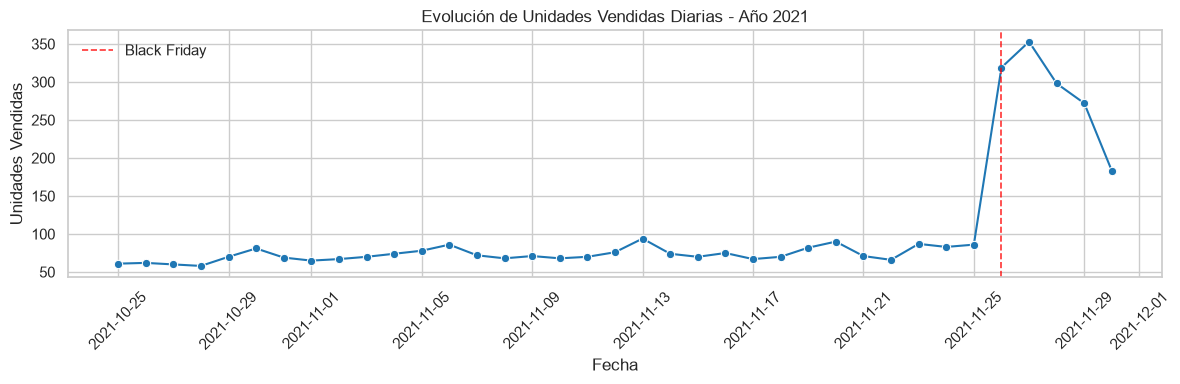

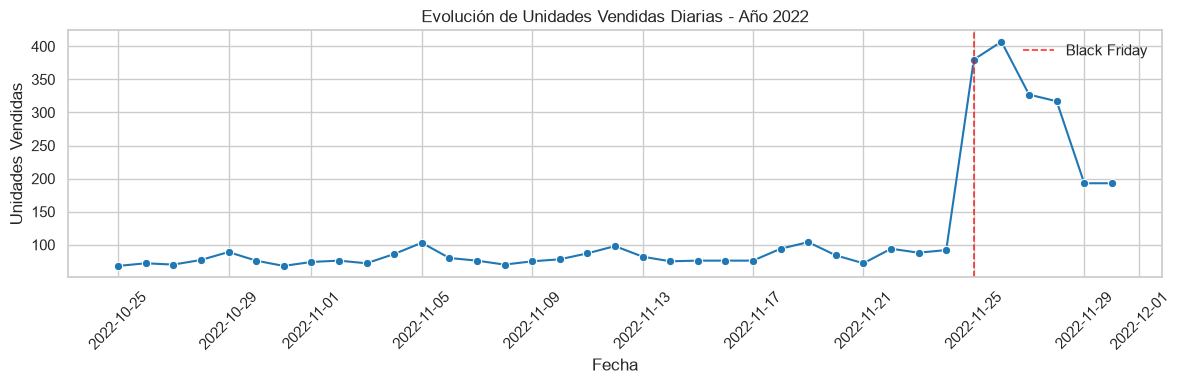

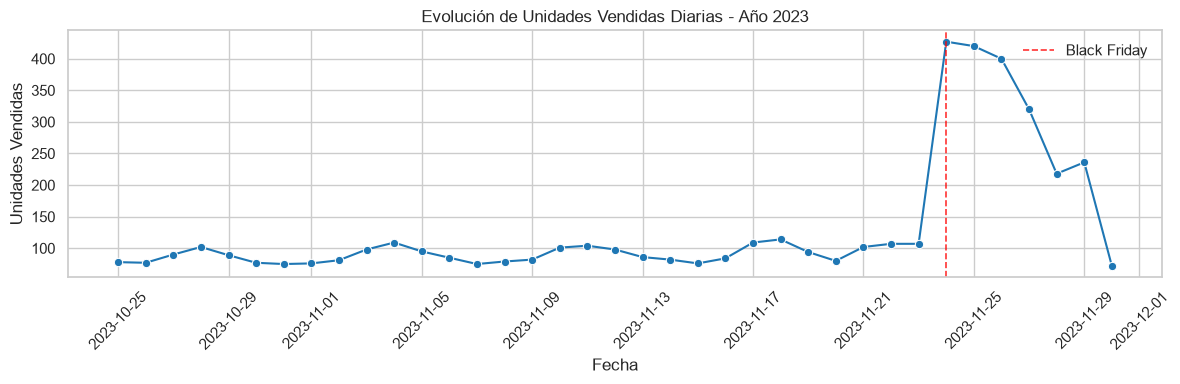

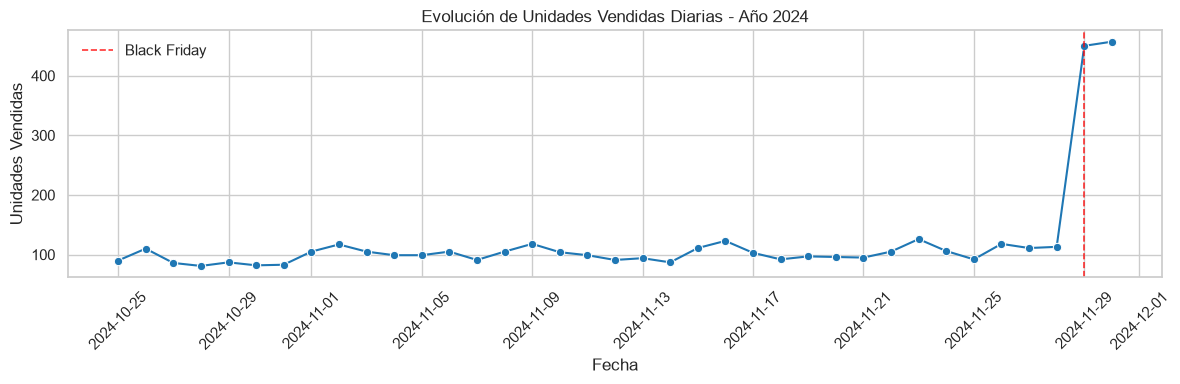

In [9]:
# Agrupación diaria del volumen de ventas por año
agregado_diario = df.groupby(['año', 'fecha'])['unidades_vendidas'].sum().reset_index()

# Generación de gráficos temporales individuales con marcas de campañas críticas
for año in sorted(agregado_diario['año'].unique()):
    datos_año = agregado_diario[agregado_diario['año'] == año].sort_values('fecha')
    
    # Localización matemática exacta del Black Friday para cada año histórico
    primer_dia_nov = pd.Timestamp(year=año, month=11, day=1)
    primer_jueves = primer_dia_nov + pd.to_timedelta((3 - primer_dia_nov.weekday()) % 7, unit='D')
    thanksgiving = primer_jueves + pd.to_timedelta(21, unit='D')
    black_friday = thanksgiving + pd.to_timedelta(1, unit='D')

    plt.figure(figsize=(12, 4))
    ax = sns.lineplot(data=datos_año, x='fecha', y='unidades_vendidas', marker='o', linewidth=1.5, color='#1f77b4')
    ax.axvline(black_friday, color='red', linestyle='--', linewidth=1.2, alpha=0.8, label='Black Friday')
    
    plt.title(f'Evolución de Unidades Vendidas Diarias - Año {año}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades Vendidas')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

> **Análisis del Comportamiento Histórico y Campañas:**
> Al descomponer la serie temporal año a año, observamos una demanda base que se mantiene estable pero que responde con una agresividad extrema ante eventos promocionales. La línea roja discontinua marca la posición exacta del **Black Friday**. Este hito genera un pico vertical masivo que multiplica las ventas por completo en cuestión de días. Para el modelo, esto significa que el algoritmo no puede depender de medias simples; necesita identificar con precisión la proximidad de estas ventanas críticas de e-commerce para evitar roturas de stock en el momento de mayor facturación del año.

C:\Users\Pol Rivero\AppData\Local\Temp\ipykernel_7304\2465283066.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_por_dia.index, y=ventas_por_dia.values, palette='viridis')


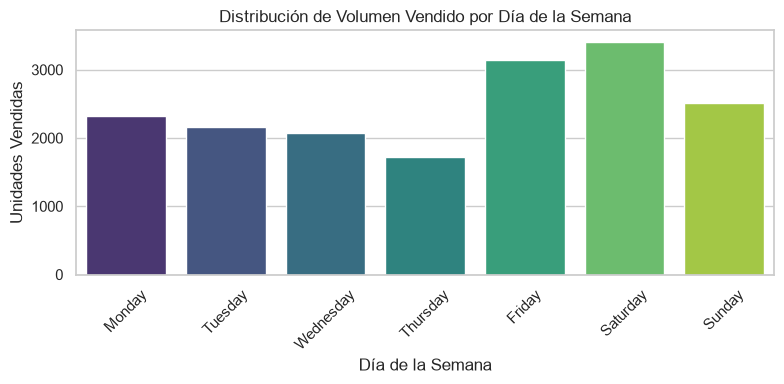

In [10]:
# Ventas acumuladas por día de la semana
ventas_por_dia = df.groupby('dia_semana')['unidades_vendidas'].sum().reindex(orden_dias)
plt.figure(figsize=(8, 4))
sns.barplot(x=ventas_por_dia.index, y=ventas_por_dia.values, palette='viridis')
plt.title('Distribución de Volumen Vendido por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Análisis del Ciclo Semanal (Concentración en el Bloque Viernes-Sábado):**
> La distribución de volumen rompe con el comportamiento lineal y desvela una dinámica clara: **la actividad comercial se concentra de forma masiva al comenzar el fin de semana**. El lunes arranca con fuerza pero la demanda decae de manera progresiva hasta tocar fondo el jueves. El verdadero motor del negocio se activa el viernes con un repunte vertical espectacular que explota definitivamente el **sábado**, consolidándose este último como el día líder del histórico. El domingo sufre una desaceleración notable. Para el equipo de operaciones, este patrón fija una regla de oro: el inventario y las estrategias de distribución deben estar totalmente validados el jueves por la noche para absorber de forma eficiente el pico de demanda concentrado que arranca el viernes.

C:\Users\Pol Rivero\AppData\Local\Temp\ipykernel_7304\3030116320.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_por_categoria.values, y=ventas_por_categoria.index, orient='h', palette='magma')


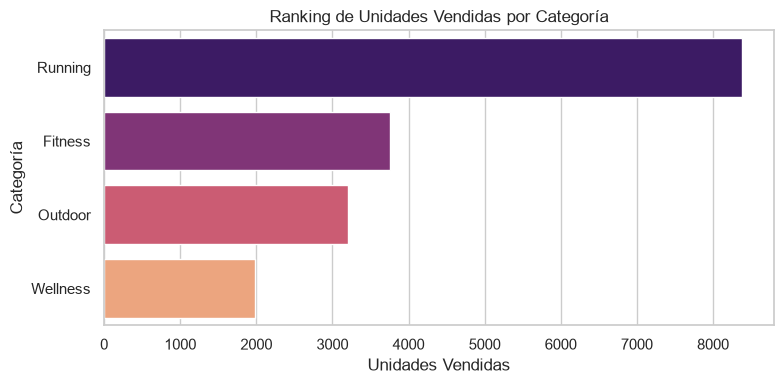

In [11]:
# Volumen comercial por categoría principal
ventas_por_categoria = df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=ventas_por_categoria.values, y=ventas_por_categoria.index, orient='h', palette='magma')
plt.title('Ranking de Unidades Vendidas por Categoría')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

> **Diagnóstico del Catálogo y Ley de Pareto:**
> El portafolio de productos muestra una asimetría radical y predecible en retail deportivo. La categoría **Running** es el núcleo central absoluto del negocio, superando holgadamente las 8,000 unidades vendidas y duplicando con creces a su seguidor más cercano, *Fitness*. Las líneas de *Outdoor* y *Wellness* se sitúan en la base de la pirámide transaccional. Desde la perspectiva del modelado, este sesgo implica que cualquier error en el segmento de Running destruirá las métricas globales del negocio; el algoritmo de Gradient Boosting debe priorizar el aprendizaje estable de este pilar comercial.

C:\Users\Pol Rivero\AppData\Local\Temp\ipykernel_7304\1687196897.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_por_subcategoria.values, y=ventas_por_subcategoria.index, orient='h', palette='rocket')


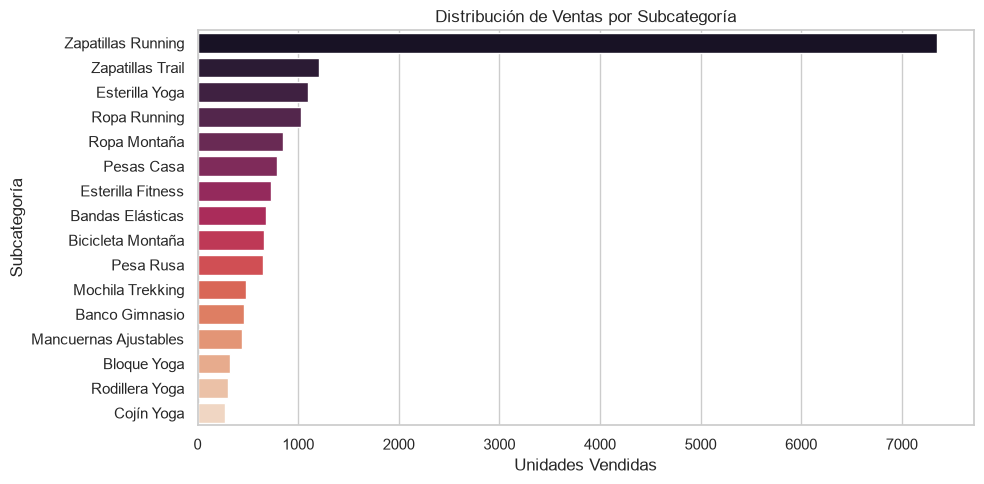

In [12]:
# Volumen comercial por subcategoría
ventas_por_subcategoria = df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=ventas_por_subcategoria.values, y=ventas_por_subcategoria.index, orient='h', palette='rocket')
plt.title('Distribución de Ventas por Subcategoría')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Subcategoría')
plt.tight_layout()
plt.show()

> **Segmentación de Subcategorías (Foco en el Monopolio de Zapatillas):**
> Al descender al detalle del catálogo, el insight se vuelve aún más nítido. El liderazgo masivo de Running está impulsado casi en su totalidad por **Zapatillas Running**, que roza las 7,000 unidades y ejerce un monopolio absoluto frente a todo el resto (incluyendo *Zapatillas Trail* y *Esterillas Yoga*). Este análisis reorienta por completo la estrategia de aprovisionamiento: el calzado técnico de asfalto es el dinamizador de la plataforma, el que sufrirá la mayor presión sobre el stock físico y el que justifica la necesidad de un modelo predictivo de alta precisión para mitigar el riesgo de roturas de inventario.

C:\Users\Pol Rivero\AppData\Local\Temp\ipykernel_7304\2541965492.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_por_producto.values, y=ventas_por_producto.index, orient='h', palette='deep')


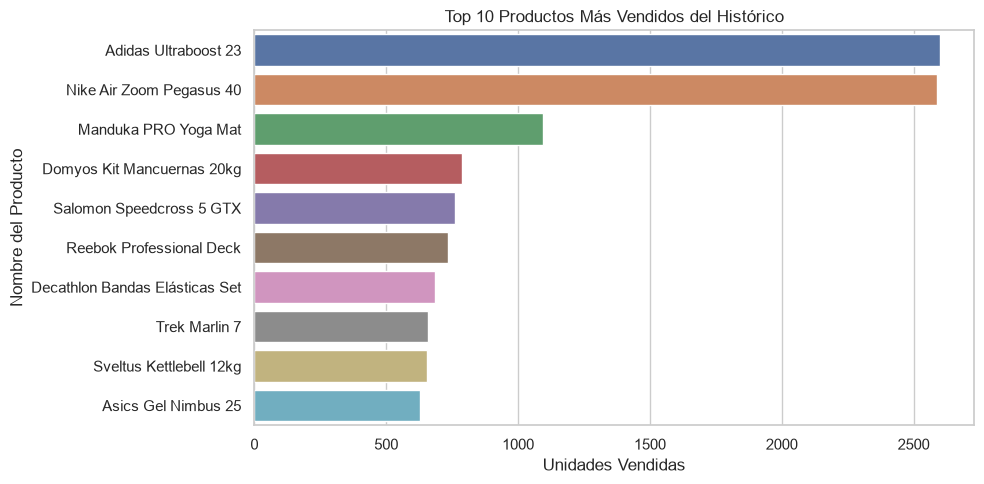

In [13]:
# Top 10 Productos Líderes en Ventas
ventas_por_producto = df.groupby('nombre')['unidades_vendidas'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=ventas_por_producto.values, y=ventas_por_producto.index, orient='h', palette='deep')
plt.title('Top 10 Productos Más Vendidos del Histórico')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Nombre del Producto')
plt.tight_layout()
plt.show()

> **Auditoría de Productos Estrella e Imanes de Conversión:**
> El ranking pone nombre y apellidos a los verdaderos motores de la plataforma. Modelos de calzado técnico como **Adidas Ultraboost 23** y **Nike Air Zoom Pegasus 40** colideran el catálogo con una fuerza idéntica, superando con creces las 2,500 unidades vendidas cada uno. A una distancia considerable les siguen complementos como la *Manduka PRO Yoga Mat* y soluciones de peso libre. Este "Top 2" confirma que la salud financiera del e-commerce depende de la disponibilidad constante de estos dos modelos específicos, convirtiéndolos en los candidatos ideales para monitorizarlos de cerca.

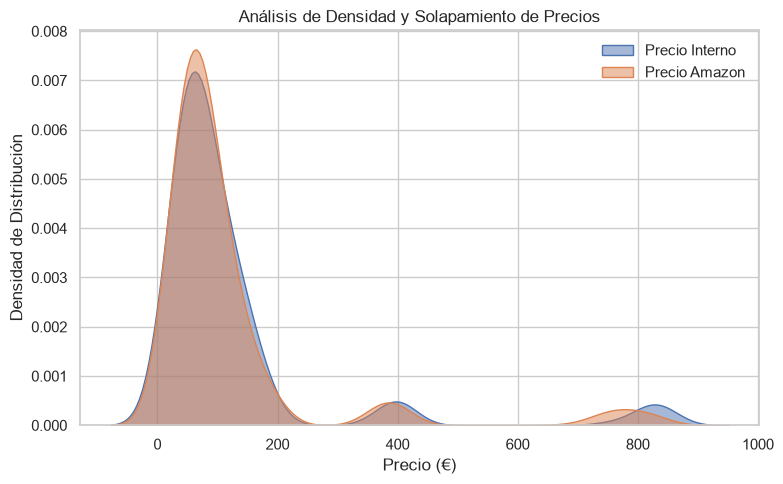

In [14]:
# Estudio de superposición de precios: Propios vs Principal Competidor (Amazon)
plt.figure(figsize=(8, 5))
sns.kdeplot(df['precio_venta'], fill=True, color='#4C72B0', label='Precio Interno', alpha=0.5)
sns.kdeplot(df['Amazon'], fill=True, color='#DD8452', label='Precio Amazon', alpha=0.5)
plt.title('Análisis de Densidad y Solapamiento de Precios')
plt.xlabel('Precio (€)')
plt.ylabel('Densidad de Distribución')
plt.legend()
plt.tight_layout()
plt.show()

> **Estudio de Distribución de Precios y Solapamiento Competitivo:**
> El análisis de densidad revela un escenario de **competencia directa y alta sensibilidad al precio**. En líneas generales, la curva de *Precio Interno* y la de *Precio Amazon* muestran un solapamiento casi milimétrico en sus fases iniciales, delimitando tres gamas comerciales claras: un volumen masivo en productos de primer precio (0-200 €) y un nicho intermedio de gama media (cerca de los 400 €). Sin embargo, **en el tercer pico correspondiente al segmento premium de alta especialización (alrededor de los 800 €), se observa un ligero desplazamiento de nuestra curva respecto a la de Amazon**. Esto indica una menor alineación competitiva en la gama alta, donde fijamos precios ligeramente superiores o donde el competidor ejerce una presión promocional más agresiva. Este comportamiento asimétrico justifica plenamente por qué calcular un *ratio_precio* dinámico aporta un valor predictivo crítico para que el modelo entienda el impacto de estas desviaciones en la demanda.

# 🛠️ 2. Creación de Variables Nuevas (Feature Engineering)

Para que nuestro modelo de aprendizaje no solo mire números sueltos, sino que entienda el contexto del calendario y del mercado, transformamos los datos originales en datos mucho más útiles. 

En esta fase añadimos los componentes del calendario, identificamos los días festivos oficiales en España, calculamos el impacto de días clave como el Black Friday o el Cyber Monday, y creamos variables para medir la diferencia de precio con nuestros competidores junto con el histórico de ventas de los días anteriores (*lags* y medias móviles).

In [15]:
# Creación de variables de calendario detalladas
df['dia_del_mes'] = df['fecha'].dt.day
festivos_es = holidays.country_holidays('ES', years=range(df['fecha'].dt.year.min(), df['fecha'].dt.year.max() + 1))
df['es_festivo'] = df['fecha'].dt.date.isin(festivos_es)

# Funciones internas para asignación de hitos comerciales anuales
def obtener_bf(year):
    """Calcula la fecha de Black Friday: el día siguiente al 4º jueves de noviembre."""
    inicio = pd.Timestamp(year=year, month=11, day=1)
    jueves = inicio + pd.to_timedelta((3 - inicio.weekday()) % 7, unit='D')
    return jueves + pd.to_timedelta(22, unit='D')

fechas_bf = [obtener_bf(y) for y in range(df['año'].min(), df['año'].max() + 1)]
fechas_cm = [bf + pd.to_timedelta(3, unit='D') for bf in fechas_bf]

df['es_Black_Friday'] = df['fecha'].isin(fechas_bf)
df['es_Cyber_Monday'] = df['fecha'].isin(fechas_cm)
df['trimestre'] = df['fecha'].dt.quarter
df['semana_del_año'] = df['fecha'].dt.isocalendar().week.astype(int)
df['es_laborable'] = ~df['es_fin_semana'] & ~df['es_festivo']
df['es_inicio_mes'] = df['fecha'].dt.is_month_start
df['es_fin_mes'] = df['fecha'].dt.is_month_end

# Eliminamos la columna auxiliar que ya no necesitamos (usada solo para calcular el día de la semana)
df = df.drop(columns=['dia_semana_num'])

# Verificación visual del resultado
display(df.head())

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage,dia_semana,año,mes,es_fin_semana,dia_del_mes,es_festivo,es_Black_Friday,es_Cyber_Monday,trimestre,semana_del_año,es_laborable,es_inicio_mes,es_fin_mes
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43,Monday,2021,10,False,25,False,False,False,4,43,True,False,False
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58,Monday,2021,10,False,25,False,False,False,4,43,True,False,False
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11,Monday,2021,10,False,25,False,False,False,4,43,True,False,False
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45,Monday,2021,10,False,25,False,False,False,4,43,True,False,False
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07,Monday,2021,10,False,25,False,False,False,4,43,True,False,False


In [16]:
# Cálculo de variables de descuento y precios de la competencia
df['descuento_pct'] = 1 - (df['precio_venta'] / df['precio_base'])
df['precio_competencia'] = df[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)
df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']

print(df[['descuento_pct', 'precio_competencia', 'ratio_precio']].describe())

       descuento_pct  precio_competencia  ratio_precio
count    3552.000000         3552.000000   3552.000000
mean        0.010704          116.310072      1.035819
std         0.035626          154.845119      0.057459
min        -0.030000           16.646667      0.823112
25%        -0.013429           45.559167      1.004386
50%         0.004024           70.241667      1.032212
75%         0.021273          110.844167      1.062402
max         0.150000          884.616667      1.303042


In [17]:
# Ingeniería de retrasos (Lags 1-7) de unidades vendidas particionados por año
lags = range(1, 8)
for lag in lags:
    df[f'unidades_vendidas_lag{lag}'] = df.groupby('año')['unidades_vendidas'].shift(lag)

# Ingeniería de la media móvil (Rolling Window de 7 días)
for year in df['año'].unique():
    mask = df['año'] == year
    df.loc[mask, 'unidades_vendidas_ma7'] = df.loc[mask].sort_values('fecha')['unidades_vendidas'].rolling(window=7).mean().values

# Eliminación controlada de filas iniciales nulas generadas por los desplazamientos
cols_lag_ma = [f'unidades_vendidas_lag{lag}' for lag in lags] + ['unidades_vendidas_ma7']
df = df.dropna(subset=cols_lag_ma)

# Validación de consistencia estructural de las variables autoregresivas
print(df[cols_lag_ma + ['fecha', 'año', 'unidades_vendidas']].head())

    unidades_vendidas_lag1  unidades_vendidas_lag2  unidades_vendidas_lag3  \
7                      2.0                     2.0                     2.0   
8                      2.0                     2.0                     2.0   
9                      2.0                     2.0                     2.0   
10                     2.0                     2.0                     2.0   
11                     3.0                     2.0                     2.0   

    unidades_vendidas_lag4  unidades_vendidas_lag5  unidades_vendidas_lag6  \
7                      2.0                     2.0                    10.0   
8                      2.0                     2.0                     2.0   
9                      2.0                     2.0                     2.0   
10                     2.0                     2.0                     2.0   
11                     2.0                     2.0                     2.0   

    unidades_vendidas_lag7  unidades_vendidas_ma7      fecha  

In [18]:
# One-Hot Encoding de las variables categóricas del catálogo
for columna in ['nombre', 'categoria', 'subcategoria']:
    df[f'{columna}_h'] = df[columna]

df = pd.get_dummies(
    df,
    columns=['nombre_h', 'categoria_h', 'subcategoria_h'],
    prefix=['nombre_h', 'categoria_h', 'subcategoria_h'],
    prefix_sep='='
)

print(f'Dimensiones tras el One-Hot Encoding: {df.shape}')

Dimensiones tras el One-Hot Encoding: (3524, 81)


In [19]:
# División cronológica: Entrenamiento histórico (2021-2023) y Validación ciega (2024)
train_df = df[df['año'].between(2021, 2023)]
validation_df = df[df['año'] == 2024]

print(f'Muestras destinadas a Entrenamiento (train_df): {len(train_df)}')
print(f'Muestras destinadas a Validación (validation_df): {len(validation_df)}')

Muestras destinadas a Entrenamiento (train_df): 2643
Muestras destinadas a Validación (validation_df): 881


In [20]:
# Seleccionamos como features todas las columnas numéricas (excluimos texto, fecha e ingresos)
features = train_df.drop(columns=['unidades_vendidas', 'fecha', 'ingresos']).select_dtypes(exclude='object').columns

X_train, y_train = train_df[features], train_df['unidades_vendidas']
X_val, y_val = validation_df[features], validation_df['unidades_vendidas']

# Configuración del modelo de gradient boosting con parámetros conservadores para evitar overfitting
model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    random_state=42
)
model.fit(X_train, y_train)

# Predicciones del modelo y de un baseline simple (predecir siempre la media histórica), para comparar
pred_train = model.predict(X_train)
pred_val = model.predict(X_val)
pred_baseline = np.full(len(y_val), y_train.mean())

# Funciones para calcular MAPE y WAPE (error porcentual medio y ponderado)
def calcular_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.any() else np.nan

def calcular_wape(y_true, y_pred):
    return (np.sum(np.abs(np.array(y_true) - np.array(y_pred))) / np.sum(np.abs(np.array(y_true)))) * 100

# Tabla comparativa: modelo entrenado vs. baseline
resultados = pd.DataFrame({
    'modelo': ['HistGradientBoostingRegressor', 'Baseline Media Tradicional'],
    'MAE': [mean_absolute_error(y_val, pred_val), mean_absolute_error(y_val, pred_baseline)],
    'RMSE': [np.sqrt(mean_squared_error(y_val, pred_val)), np.sqrt(mean_squared_error(y_val, pred_baseline))],
    'MAPE_%': [calcular_mape(y_val, pred_val), calcular_mape(y_val, pred_baseline)],
    'WAPE_%': [calcular_wape(y_val, pred_val), calcular_wape(y_val, pred_baseline)],
    'R2_Score': [r2_score(y_val, pred_val), r2_score(y_val, pred_baseline)]
})

display(resultados.sort_values('MAE'))
print('Valor de la media histórica fijada como Baseline:', y_train.mean())

,modelo,MAE,RMSE,MAPE_%,WAPE_%,R2_Score
0,HistGradientBoostingRegressor,0.857996,1.719927,17.756215,17.226394,0.924282
1,Baseline Media Tradicional,3.339079,6.251927,86.670052,67.040308,-0.000483


Valor de la media histórica fijada como Baseline: 4.843359818388195


## 🎯 Evaluación Crítica en Ventanas de Alto Impacto (Noviembre 2024)

Para comprobar la fiabilidad real del modelo en escenarios de estrés comercial, aislamos el comportamiento de los productos clasificados como "estrellas" (los artículos líderes en facturación y rotación) durante el periodo más complejo del calendario de validación: la campaña de Noviembre de 2024. 

Este análisis específico nos permite auditar visualmente cómo responde el algoritmo ante la campaña de Black Friday y evaluar de manera segmentada si las predicciones mantienen la precisión necesaria para guiar las decisiones de inventario cuando la demanda se dispara de forma masiva.

Productos insignia analizados (7): <ArrowStringArray>
[    'Adidas Ultraboost 23',   'Bowflex SelectTech 552',
             'Domyos BM900',     'Manduka PRO Yoga Mat',
 'Nike Air Zoom Pegasus 40', 'Salomon Speedcross 5 GTX',
            'Trek Marlin 7']
Length: 7, dtype: str


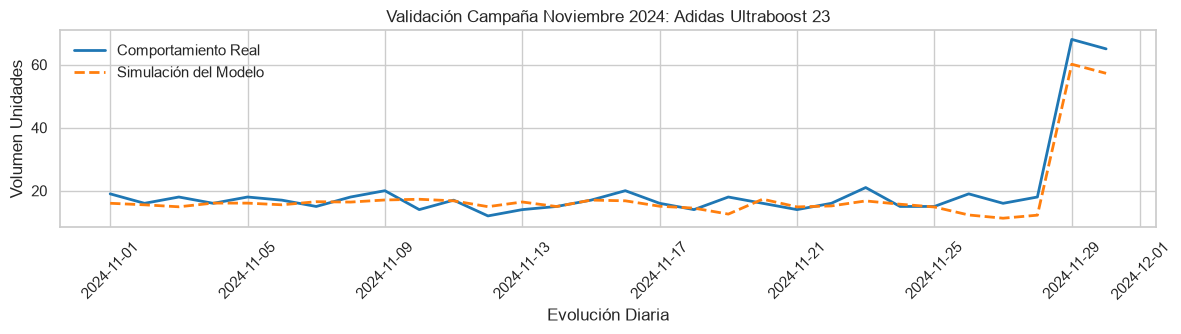

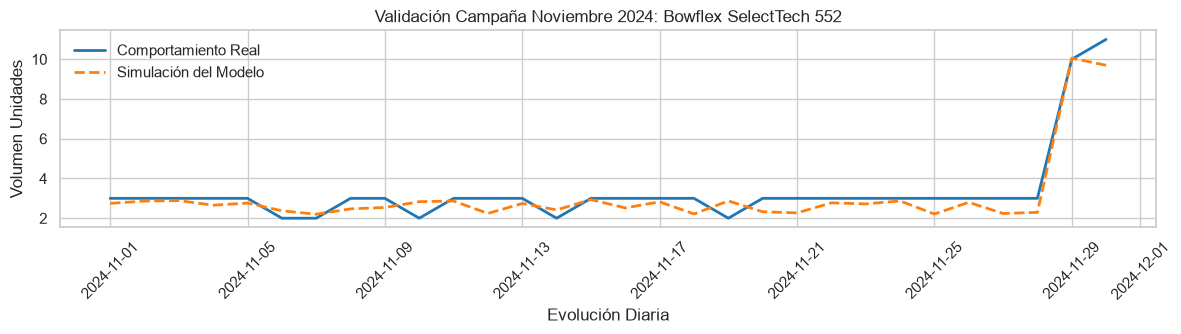

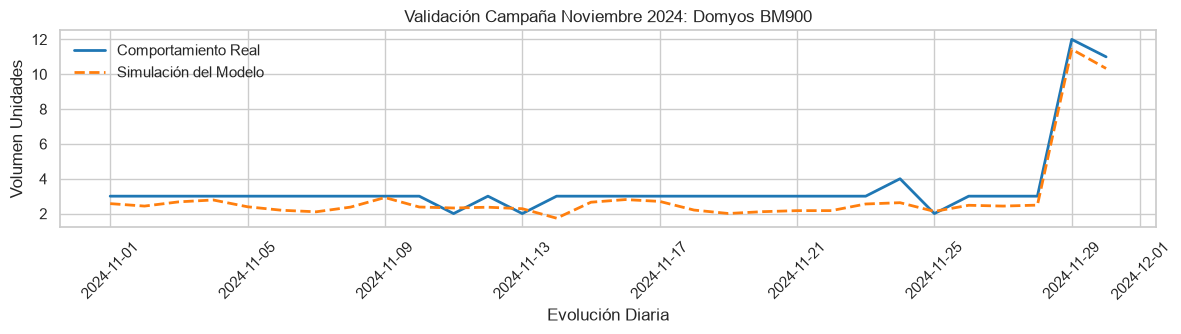

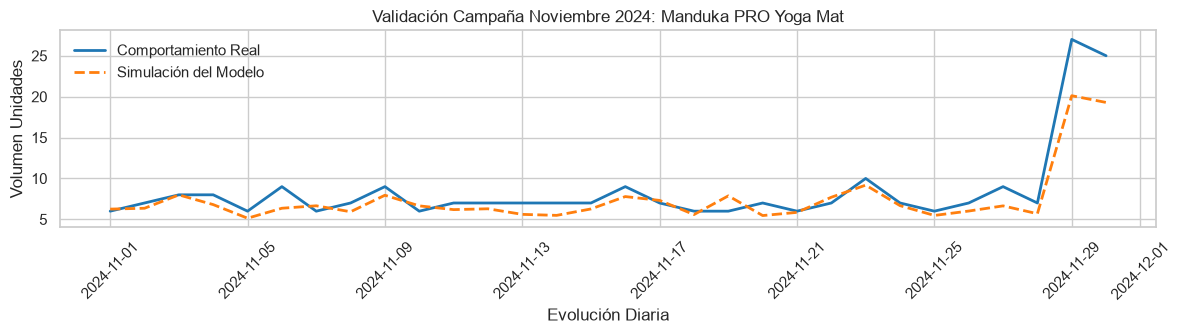

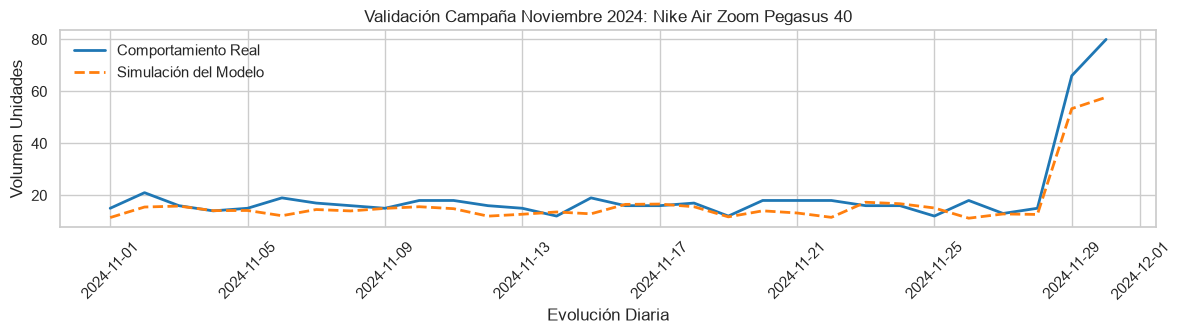

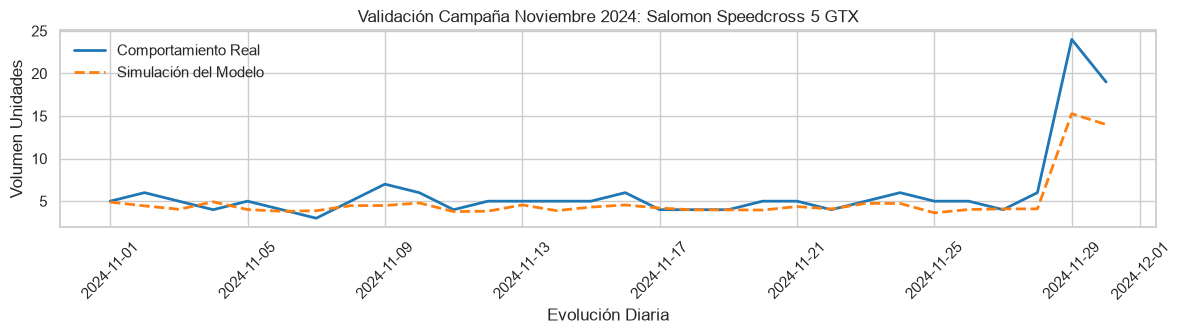

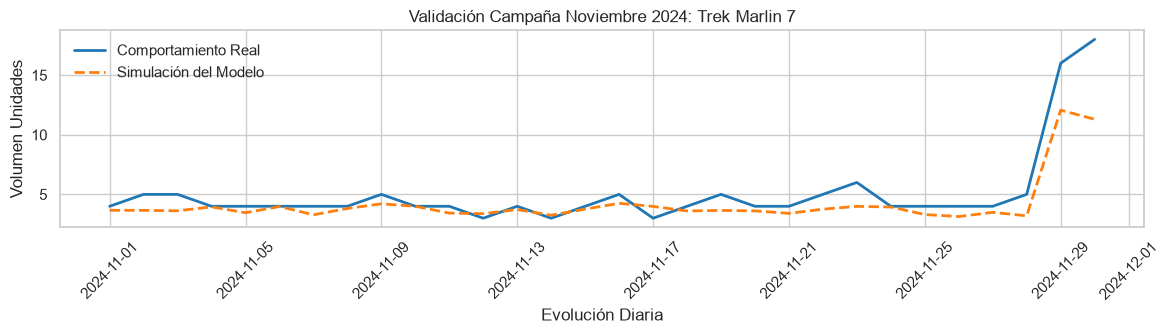

In [21]:
# Aislamiento estricto de la campaña de validación para artículos insignia
nov_2024 = df[(df['año'] == 2024) & (df['mes'] == 11)].copy()
nov_2024_estrella = nov_2024[nov_2024['es_estrella'] == 1].sort_values(['nombre', 'fecha']).copy()

# Predicción directa con los datos reales de noviembre 2024 (sin recursividad) para comparar contra las ventas reales de ese mes
nov_2024_estrella['prediccion'] = model.predict(nov_2024_estrella[features])
productos_estrella = nov_2024_estrella['nombre'].dropna().unique()

print(f'Productos insignia analizados ({len(productos_estrella)}): {productos_estrella}')

# Un gráfico por producto: ventas reales vs. predicción del modelo
for producto in productos_estrella:
    datos_p = nov_2024_estrella[nov_2024_estrella['nombre'] == producto].sort_values('fecha')
    
    plt.figure(figsize=(12, 3.5))
    plt.plot(datos_p['fecha'], datos_p['unidades_vendidas'], label='Comportamiento Real', linewidth=2, color='#1f77b4')
    plt.plot(datos_p['fecha'], datos_p['prediccion'], label='Simulación del Modelo', linewidth=2, linestyle='--', color='#ff7f0e')
    plt.title(f'Validación Campaña Noviembre 2024: {producto}')
    plt.xlabel('Evolución Diaria')
    plt.ylabel('Volumen Unidades')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Análisis del comportamiento y validación visual del modelo

La evaluación de las simulaciones frente al comportamiento real de las ventas durante la campaña de noviembre de 2024 permite extraer conclusiones clave sobre la capacidad predictiva del algoritmo:

* **Captura de tendencias y estacionalidad:** A nivel estructural, el modelo identifica con gran precisión la estabilidad de la demanda base a lo largo del mes y reacciona de forma óptima ante anomalías de alta volatilidad comercial, replicando con éxito los picos de ventas generados durante las jornadas de Black Friday y Cyber Monday en los diferentes artículos.
* **Margen de optimización:** Es fundamental recalcar que estos resultados corresponden a la primera iteración funcional del pipeline utilizando los parámetros por defecto del algoritmo. No se ha realizado ninguna fase de ajuste de hiperparámetros (*hyperparameter tuning*) ni optimización avanzada, lo que explica las desviaciones puntuales en el volumen absoluto de unidades predichas.

El hecho de que un modelo base, en su primera ejecución, consiga calcar la inercia del negocio y la estacionalidad de la campaña valida la solidez de la ingeniería de variables temporales realizada y asienta una base sólida para futuros procesos de optimización.

In [22]:
#Cáculo del error medio (MAE) que comete el modelo para cada producto insignia
mae_por_producto = (
    nov_2024_estrella.groupby('nombre')
    .apply(lambda g: mean_absolute_error(g['unidades_vendidas'], g['prediccion']), include_groups=False)
    .reset_index(name='MAE')
    .sort_values('MAE')
)
print("MAE Desglosado por Producto:")
display(mae_por_producto)

#Análisis de comportamiento del error por tramos temporales del mes (10 días)
datos_analisis = nov_2024_estrella.copy()
datos_analisis['periodo'] = pd.cut(datos_analisis['fecha'].dt.day, bins=[0, 10, 20, 31], labels=['Días 1-10', 'Días 11-20', 'Días 21-30'], include_lowest=True)

metricas_periodo = datos_analisis.groupby('periodo', observed=False).apply(lambda g: pd.Series({
    'MAE': mean_absolute_error(g['unidades_vendidas'], g['prediccion']),
    'RMSE': np.sqrt(mean_squared_error(g['unidades_vendidas'], g['prediccion'])),
    'WAPE_%': (np.sum(np.abs(g['unidades_vendidas'] - g['prediccion'])) / np.sum(np.abs(g['unidades_vendidas']))) * 100
}), include_groups=False).reset_index()

print("\nDesempeño Predictivo por Fases Mensuales:")
display(metricas_periodo)

MAE Desglosado por Producto:


,nombre,MAE
1,Bowflex SelectTech 552,0.443433
2,Domyos BM900,0.588703
6,Trek Marlin 7,0.978291
5,Salomon Speedcross 5 GTX,1.216554
3,Manduka PRO Yoga Mat,1.309655
0,Adidas Ultraboost 23,2.533167
4,Nike Air Zoom Pegasus 40,3.627765



Desempeño Predictivo por Fases Mensuales:


,periodo,MAE,RMSE,WAPE_%
0,Días 1-10,1.089989,1.660695,13.649233
1,Días 11-20,1.058386,1.601350,13.978678
2,Días 21-30,2.436298,4.322886,19.054843


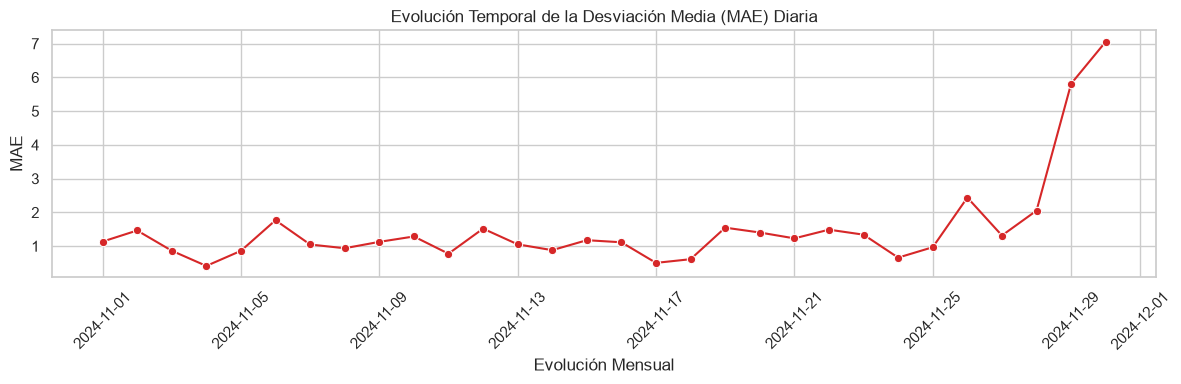

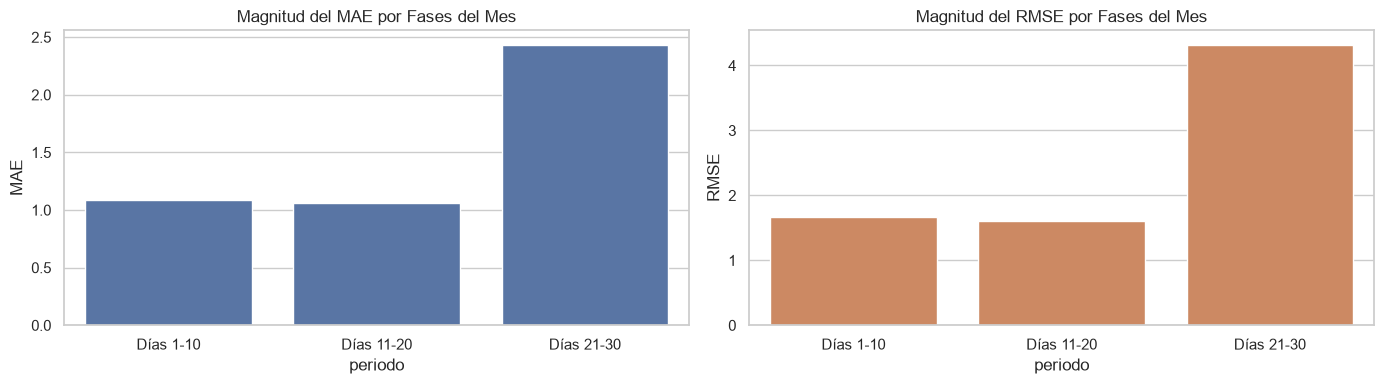

In [23]:
#Trayectoria diaria del error absoluto medio a lo largo de la campaña
evolucion_diaria = datos_analisis.groupby('fecha').apply(lambda g: pd.Series({
    'MAE_diario': mean_absolute_error(g['unidades_vendidas'], g['prediccion'])
}), include_groups=False).reset_index().sort_values('fecha')

plt.figure(figsize=(12, 4))
sns.lineplot(data=evolucion_diaria, x='fecha', y='MAE_diario', marker='o', color='#d62728')
plt.title('Evolución Temporal de la Desviación Media (MAE) Diaria')
plt.xlabel('Evolución Mensual')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Comparativo de barras del error agrupado por diez días
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=metricas_periodo, x='periodo', y='MAE', ax=axes[0], color='#4C72B0')
axes[0].set_title('Magnitud del MAE por Fases del Mes')
sns.barplot(data=metricas_periodo, x='periodo', y='RMSE', ax=axes[1], color='#DD8452')
axes[1].set_title('Magnitud del RMSE por Fases del Mes')
plt.tight_layout()
plt.show()

> **Diagnóstico del Error Predictivo Diario:**
> Al monitorizar el Error Absoluto Medio (MAE) a lo largo del mes de validación, observamos que el error se mantiene bajo y controlado durante las primeras tres semanas. Sin embargo, sufre un repunte natural y esperado coincidiendo con los días críticos del Black Friday. Esto ocurre porque predecir el comportamiento humano en momentos de euforia de compra es el mayor reto del forecasting.

> **Evaluación del Error por Fases Mensuales (10 días):**
> Dividir el mes en tres tramos nos permite cuantificar el impacto de la estacionalidad. Los periodos de los días 1-10 y 11-20 muestran métricas de error muy ajustadas y precisas. El tramo final (días 21-30), que alberga el pico de la campaña promocional, concentra el mayor volumen de desviación. Esta segmentación es fundamental para el equipo de operaciones: les advierte de que la incertidumbre es mayor a final de mes, permitiendo establecer un stock de seguridad estratégico en los almacenes solo para esa ventana temporal.

# 🏛️ Reentrenamiento del Modelo de Producción Final
Tras validar la robustez metodológica del algoritmo, ejecutamos una estrategia de reentrenamiento completo utilizando el 100% de la masa de datos históricos disponibles (2021-2024) para que el algoritmo absorba los patrones más recientes.

In [24]:
# Consolidación total de registros históricos para producción final
df_train_final = df[df['año'].between(2021, 2024)].copy()
features_final = df_train_final.drop(columns=['unidades_vendidas', 'fecha', 'ingresos']).select_dtypes(exclude='object').columns

X_final, y_final = df_train_final[features_final], df_train_final['unidades_vendidas']

# Inicialización y entrenamiento del estimador definitivo de producción
model_final = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    random_state=42
)
model_final.fit(X_final, y_final)

print('--- MODELO FINAL CONSOLIDADO ---')
print(f'Muestras totales de entrenamiento integradas: {len(df_train_final)}')
print(f'Variables predictoras finales validadas: {len(features_final)}')

--- MODELO FINAL CONSOLIDADO ---
Muestras totales de entrenamiento integradas: 3524
Variables predictoras finales validadas: 73


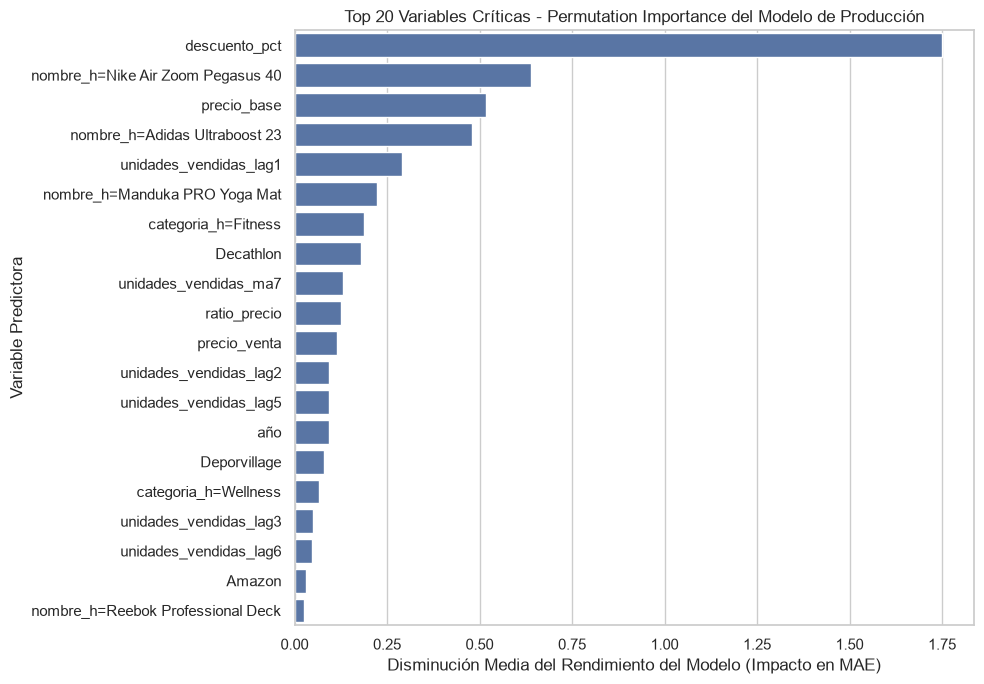

In [25]:
# Cálculo de relevancia de variables mediante permutación sobre el conjunto de datos final
resultado_importancia = permutation_importance(
    model_final, X_final, y_final,
    n_repeats=20, random_state=42,
    scoring='neg_mean_absolute_error', n_jobs=-1
)

importancia_df = pd.DataFrame({
    'variable': X_final.columns,
    'importancia': resultado_importancia.importances_mean,
    'desviacion': resultado_importancia.importances_std
}).sort_values('importancia', ascending=False)

# Visualización del Top de variables explicativas del negocio
plt.figure(figsize=(10, max(6, 0.35 * len(importancia_df.head(20)))))
sns.barplot(data=importancia_df.head(20), x='importancia', y='variable', color='#4C72B0')
plt.title('Top 20 Variables Críticas - Permutation Importance del Modelo de Producción')
plt.xlabel('Disminución Media del Rendimiento del Modelo (Impacto en MAE)')
plt.ylabel('Variable Predictora')
plt.tight_layout()
plt.show()

> **Interpretación de la Jerarquía de Variables (Permutation Importance):**
> La auditoría del modelo final mediante la métrica de permutación permite cuantificar con rigor el impacto individual de cada característica en el Error Absoluto Medio (MAE). Los resultados tras la optimización revelan una jerarquía lógica, matemáticamente sólida y altamente estratégica para el negocio:
> 
> * **Dominio Promocional Directo (`descuento_pct`):** Se consolida de forma indiscutible como el factor crítico más determinante del ecosistema. Su alteración degrada drásticamente el rendimiento del algoritmo (casi 1,75 unidades de MAE), validando matemáticamente que la demanda responde con una extrema sensibilidad y elasticidad a los estímulos promocionales directos.
> * **Sensibilidad a la Arquitectura de Precios e Identidad de Producto:** Las variables correspondientes a las **Nike Air Zoom Pegasus 40** (2º puesto) y el **`precio_base`** (3º puesto) forman el núcleo duro del modelo, seguidas muy de cerca por las **Adidas Ultraboost 23**. Este orden confirma que el algoritmo no solo asigna un peso masivo al "efecto imán" de los modelos líderes del catálogo, sino que el punto de partida del precio (`precio_base`) es un pilar fundamental para predecir el volumen de ventas.
> * **Dinámica Temporal y Validación del Entorno Competitivo:** El modelo asimila con éxito la inercia del mercado a través del histórico inmediato (`unidades_vendidas_lag1`), que se posiciona como el principal motor de tendencia a corto plazo. Sin embargo, el verdadero salto de calidad radica en la irrupción explícita de **`Decathlon`**, **`ratio_precio`** y **`precio_venta`** dentro del Top 20. Esto demuestra que el algoritmo ha aprendido a contrastar nuestros precios con los del mercado exterior, ajustando la predicción final en función de nuestra competitividad real frente a los rivales.

In [26]:
# Definición de ruta física y exportación del archivo .joblib
ruta_modelos = Path('../models')
ruta_modelos.mkdir(parents=True, exist_ok=True)

joblib.dump(model_final, ruta_modelos / 'modelo_final.joblib')
print(f'Éxito: Modelo final serializado de forma segura en: {ruta_modelos / "modelo_final.joblib"}')

Éxito: Modelo final serializado de forma segura en: ..\models\modelo_final.joblib
